In [1]:
import pandas as pd
import datetime as dt
from datetime import date
import matplotlib.pyplot as plt
import yfinance as yf
import numpy as np
import tensorflow as tf

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jacksoncrow/stock-market-dataset")

print("Path to dataset files:", path)

/Users/amarpritsingh/anaconda3/envs/rnn_development/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/amarpritsingh/.cache/kagglehub/datasets/jacksoncrow/stock-market-dataset/versions/2


In [3]:
df = pd.read_csv("/Users/amarpritsingh/Library/CloudStorage/OneDrive-MonashUniversity/Deepneuron-Amar's MacBook Pro/Parallel-RNN-Training/src/archive/stocks/AAPL.csv")
data = pd.read_csv("/Users/amarpritsingh/Library/CloudStorage/OneDrive-MonashUniversity/Deepneuron-Amar's MacBook Pro/Parallel-RNN-Training/src/archive/stocks/AAPL.csv")
print(df.head())

         Date      Open      High       Low     Close  Adj Close     Volume
0  1980-12-12  0.513393  0.515625  0.513393  0.513393   0.406782  117258400
1  1980-12-15  0.488839  0.488839  0.486607  0.486607   0.385558   43971200
2  1980-12-16  0.453125  0.453125  0.450893  0.450893   0.357260   26432000
3  1980-12-17  0.462054  0.464286  0.462054  0.462054   0.366103   21610400
4  1980-12-18  0.475446  0.477679  0.475446  0.475446   0.376715   18362400


In [4]:
df = df.drop(['Date', 'Adj Close'], axis = 1)
df.head()

,Open,High,Low,Close,Volume
0,0.513393,0.515625,0.513393,0.513393,117258400
1,0.488839,0.488839,0.486607,0.486607,43971200
2,0.453125,0.453125,0.450893,0.450893,26432000
3,0.462054,0.464286,0.462054,0.462054,21610400
4,0.475446,0.477679,0.475446,0.475446,18362400


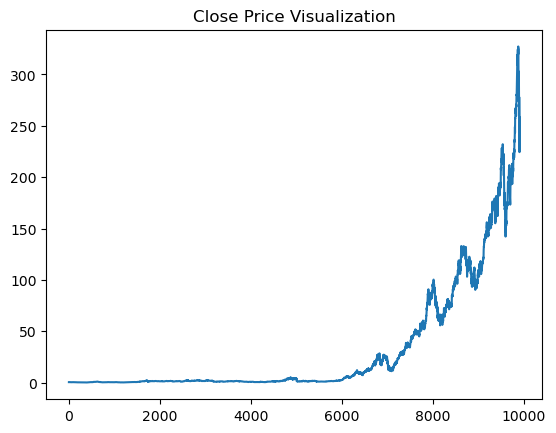

In [5]:
plt.title("Close Price Visualization")
plt.plot(df.Close)

In [6]:
ma100 = df.Close.rolling(100).mean()
ma100

0              NaN
1              NaN
2              NaN
3              NaN
4              NaN
           ...    
9904    285.387599
9905    285.306799
9906    285.279899
9907    285.251499
9908    285.088199
Name: Close, Length: 9909, dtype: float64

Text(0.5, 1.0, 'Graph Of Moving Averages Of 100 Days')

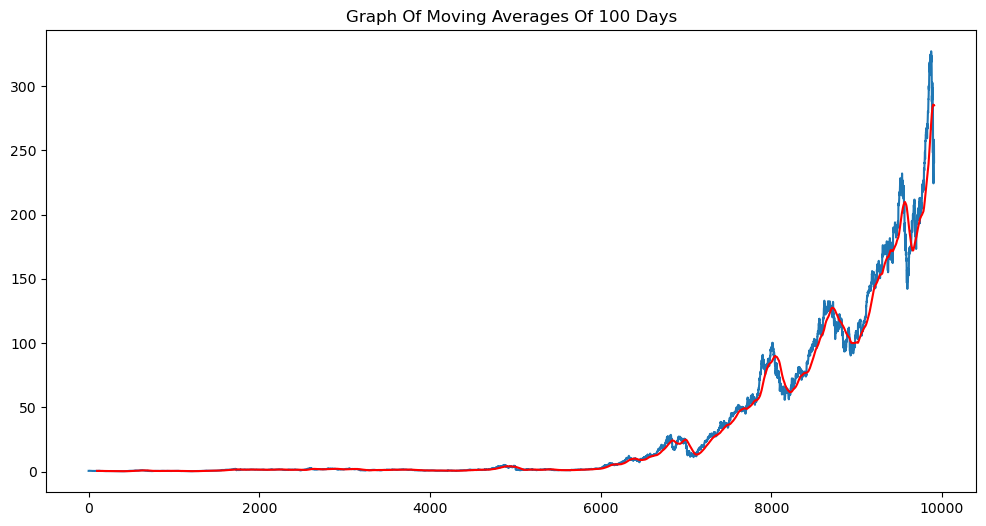

In [7]:
# MOVING AVERAGE #

plt.figure(figsize = (12,6))
plt.plot(df.Close)
plt.plot(ma100, 'r')
plt.title('Graph Of Moving Averages Of 100 Days')

In [8]:
ma200 = df.Close.rolling(200).mean()
ma200

0             NaN
1             NaN
2             NaN
3             NaN
4             NaN
          ...    
9904    249.47610
9905    249.74385
9906    250.04715
9907    250.35490
9908    250.59000
Name: Close, Length: 9909, dtype: float64

Text(0.5, 1.0, '100 Days vs 200 Days Moving Averages')

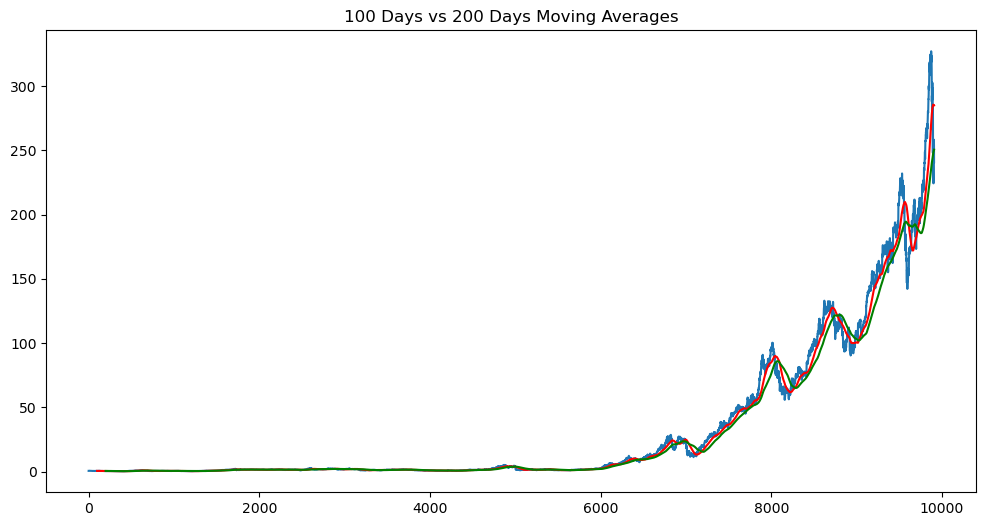

In [9]:
plt.figure(figsize = (12,6))
plt.plot(df.Close)
plt.plot(ma100, 'r')
plt.plot(ma200, 'g')
plt.title('100 Days vs 200 Days Moving Averages')

In [10]:
df.shape

(9909, 5)

In [11]:
# Splitting data into training and testing

train = pd.DataFrame(data[0:int(len(data)*0.70)])
test = pd.DataFrame(data[int(len(data)*0.70): int(len(data))])

print(train.shape)
print(test.shape)

(6936, 7)
(2973, 7)


In [12]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [13]:
train_close = train.iloc[:, 4:5].values
test_close = test.iloc[:, 4:5].values

In [14]:
data_training_array = scaler.fit_transform(train_close)
data_training_array

array([[0.01118012],
       [0.01023532],
       [0.00897559],
       ...,
       [0.92849769],
       [0.90819082],
       [0.92849769]])

In [15]:
x_train = []
y_train = [] 

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100: i])
    y_train.append(data_training_array[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train) 

In [16]:
x_train.shape

(6836, 100, 1)

ML MODEL

In [17]:
from tensorflow.keras.layers import Dense, Dropout, LSTM
from tensorflow.keras.models import Sequential

In [18]:
model = Sequential()
model.add(LSTM(units = 50, activation = 'relu', return_sequences=True
              ,input_shape = (x_train.shape[1], 1)))
model.add(Dropout(0.2))


model.add(LSTM(units = 60, activation = 'relu', return_sequences=True))
model.add(Dropout(0.3))


model.add(LSTM(units = 80, activation = 'relu', return_sequences=True))
model.add(Dropout(0.4))


model.add(LSTM(units = 120, activation = 'relu'))
model.add(Dropout(0.5))

model.add(Dense(units = 1))

In [19]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 100, 50)           10400     
                                                                 
 dropout (Dropout)           (None, 100, 50)           0         
                                                                 
 lstm_1 (LSTM)               (None, 100, 60)           26640     
                                                                 
 dropout_1 (Dropout)         (None, 100, 60)           0         
                                                                 
 lstm_2 (LSTM)               (None, 100, 80)           45120     
                                                                 
 dropout_2 (Dropout)         (None, 100, 80)           0         
                                                                 
 lstm_3 (LSTM)               (None, 120)               9

In [38]:
model.compile(optimizer = 'adam', loss = 'mean_squared_error', metrics = ['MAE'])
model.fit(x_train, y_train, validation_data = (x_test, y_test) ,epochs = 50)

Epoch 1/50
214/214 [==============================] - 30s 133ms/step - loss: 0.0047 - MAE: 0.0334 - val_loss: 12638.0479 - val_MAE: 90.8395
Epoch 2/50
214/214 [==============================] - 29s 134ms/step - loss: 0.0018 - MAE: 0.0225 - val_loss: 12637.4502 - val_MAE: 90.8265
Epoch 3/50
214/214 [==============================] - 28s 132ms/step - loss: 0.0018 - MAE: 0.0218 - val_loss: 12623.8438 - val_MAE: 90.7812
Epoch 4/50
214/214 [==============================] - 28s 132ms/step - loss: 0.0014 - MAE: 0.0201 - val_loss: 12637.5957 - val_MAE: 90.8300
Epoch 5/50
214/214 [==============================] - 28s 132ms/step - loss: 0.0016 - MAE: 0.0220 - val_loss: 12626.3291 - val_MAE: 90.7863
Epoch 6/50
214/214 [==============================] - 29s 135ms/step - loss: 0.0015 - MAE: 0.0207 - val_loss: 12636.6104 - val_MAE: 90.8324
Epoch 7/50
214/214 [==============================] - 29s 134ms/step - loss: 0.0015 - MAE: 0.0191 - val_loss: 12645.7500 - val_MAE: 90.8641
Epoch 8/50
214/214 [

In [39]:
model.save('keras_model.h5')

In [40]:
test_close.shape
test_close

array([[ 25.82999992],
       [ 24.7514286 ],
       [ 24.62428665],
       ...,
       [254.80999756],
       [254.28999329],
       [240.91000366]])

In [41]:
past_100_days = pd.DataFrame(train_close[-100:])

In [42]:

test_df = pd.DataFrame(test_close)

In [43]:
final_df = pd.concat([past_100_days, test_df], ignore_index=True)

In [44]:
final_df.head()

,0
0,22.984285
1,23.051428
2,22.234285
3,19.867144
4,19.371429


In [45]:
input_data = scaler.fit_transform(final_df)
input_data

array([[0.03737908],
       [0.03759153],
       [0.03500587],
       ...,
       [0.77093839],
       [0.76929296],
       [0.72695505]])

In [46]:
input_data.shape

(3073, 1)

In [47]:
x_test = []
y_test = []
for i in range(100, input_data.shape[0]):
   x_test.append(input_data[i-100: i])
   y_test.append(input_data[i, 0])

In [48]:
x_test, y_test = np.array(x_test), np.array(y_test)
print(x_test.shape)
print(y_test.shape)

(2973, 100, 1)
(2973,)


In [49]:

# Making predictions

y_pred = model.predict(x_test)

93/93 [==============================] - 5s 48ms/step


In [32]:

y_pred.shape

(2973, 1)

In [50]:
y_test

array([0.04638369, 0.0429708 , 0.04256848, ..., 0.77093839, 0.76929296,
       0.72695505])

In [51]:
y_pred

array([[0.06509618],
       [0.06545883],
       [0.06579964],
       ...,
       [0.7161539 ],
       [0.7160022 ],
       [0.7181316 ]], dtype=float32)

In [52]:
scaler.scale_

array([0.00316427])

In [53]:
scale_factor = 1/0.00316427
y_pred = y_pred * scale_factor
y_test = y_test * scale_factor

In [60]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Assuming y_pred and y_test are already scaled back

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.4f}")


MSE: 78.47
RMSE: 8.86
MAE: 6.90
R²: 0.9822


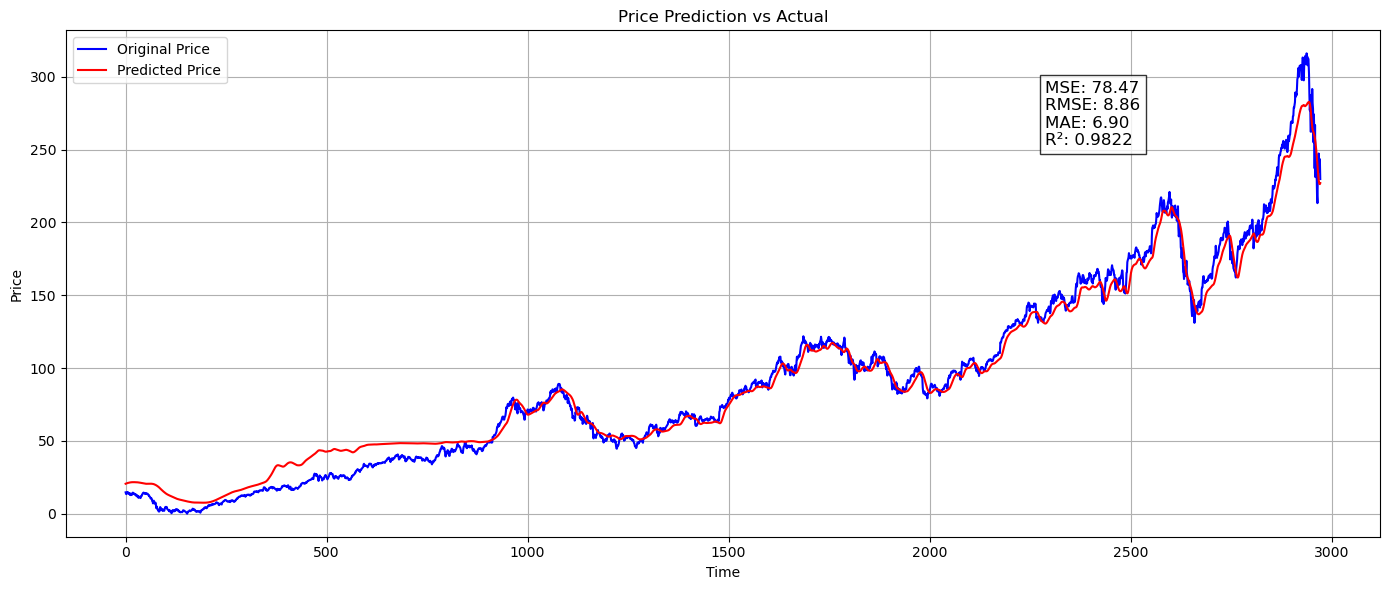

In [61]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Plot
plt.figure(figsize=(14,6))
plt.plot(y_test, label="Original Price", color='blue')
plt.plot(y_pred, label="Predicted Price", color='red')
plt.xlabel("Time")
plt.ylabel("Price")
plt.title("Price Prediction vs Actual")

# Add text box with metrics
textstr = '\n'.join((
    f'MSE: {mse:.2f}',
    f'RMSE: {rmse:.2f}',
    f'MAE: {mae:.2f}',
    f'R²: {r2:.4f}',
))
plt.gcf().text(0.75, 0.75, textstr, fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


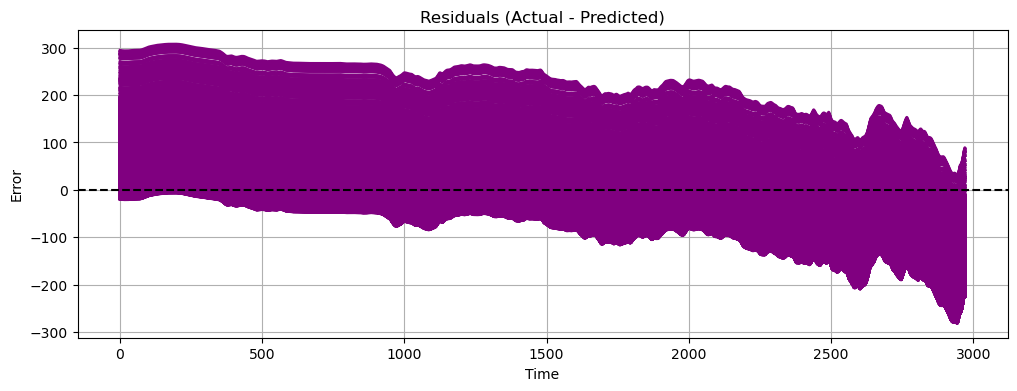

In [62]:
residuals = y_test - y_pred

plt.figure(figsize=(12,4))
plt.plot(residuals, color='purple')
plt.axhline(0, color='black', linestyle='--')
plt.title("Residuals (Actual - Predicted)")
plt.xlabel("Time")
plt.ylabel("Error")
plt.grid(True)
plt.show()


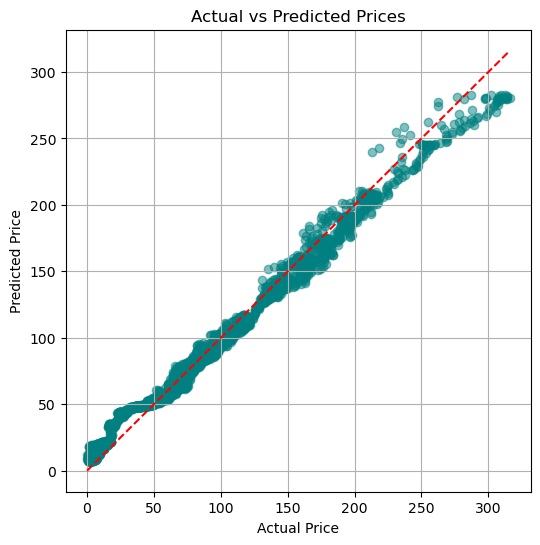

In [59]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.grid(True)
plt.show()
